# Polynomial Regression

When your data is more complex than a straight line, you can still use a **linear model** to fit **nonlinear data**.

The key idea is to **extend** the feature set by adding **powers of the original features**. Then, a simple linear regression can fit these transformed features.

This technique is called **Polynomial Regression**.


## Mathematical Formulation

A standard linear regression model assumes:

$$
\hat{y} = \theta_0 + \theta_1 x
$$

Polynomial Regression extends this by adding higher-degree terms of the feature:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \cdots + \theta_d x^d
$$

Although this model is **nonlinear in $ x $**, it is still **linear in the parameters** $ \theta_0, \theta_1, \dots, \theta_d $, which means it can be trained using the same linear regression algorithms.


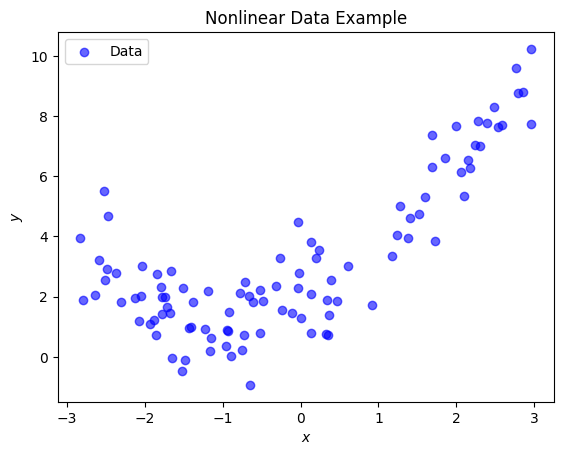

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate nonlinear data based on a quadratic relationship
m = 100  # number of samples
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1) #y = 0.5x^2+1.0x+2+\eps

# Visualize the data
plt.scatter(X, y, color="blue", alpha=0.6, label="Data")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Nonlinear Data Example")
plt.legend()
plt.show()


Clearly, a straight line will never fit this data properly. So let’s use Scikit-Learn’s Poly
nomialFeatures class to transform our training data, adding the square (second-
degree polynomial) of each feature in the training set as a new feature (in this case
there is just one feature):


In [2]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
print('original feature: ',X[0])

print('new added feature:', X_poly[0])


original feature:  [-0.92352706]
new added feature: [-0.92352706  0.85290224]


## Polynomial Feature Transformation

To fit nonlinear data using a linear model, we create **polynomial features**:

$$
X_{\text{poly}} = 
\begin{bmatrix}
1 & x & x^2 & \cdots & x^d
\end{bmatrix}
$$

For example, if $ x = 2 $ and we use degree $ d = 3 $:

$$
X_{\text{poly}} = [1, 2, 4, 8]
$$


In [3]:
from sklearn.preprocessing import PolynomialFeatures

# Transform the features into polynomial form
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print("Original feature shape:", X.shape)
print("Transformed feature shape:", X_poly.shape)
print("First 5 original samples:\n", X[:5])
print("First 5 transformed samples:\n", X_poly[:5])


Original feature shape: (100, 1)
Transformed feature shape: (100, 2)
First 5 original samples:
 [[-0.92352706]
 [-0.71513768]
 [-1.51477768]
 [-2.79619532]
 [-2.50582361]]
First 5 transformed samples:
 [[-0.92352706  0.85290224]
 [-0.71513768  0.5114219 ]
 [-1.51477768  2.29455141]
 [-2.79619532  7.81870829]
 [-2.50582361  6.27915198]]


X_poly now contains the original feature of $X$ plus the square of this feature.   
Now you
can fit a LinearRegression model to this extended training data 


## Fitting the Model

Now that we have polynomial features, we can use **Linear Regression** to fit the model:

$$
\hat{y} = \theta_0 + \theta_1 x + \theta_2 x^2
$$

Even though the relationship between $ x $ and $ y $ is quadratic, the model remains **linear in parameters**.


In [4]:
from sklearn.linear_model import LinearRegression

# Train a linear regression model on the polynomial features
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# Display model parameters
print(f"θ₀ (intercept): {lin_reg.intercept_[0]:.4f}")
print(f"θ₁, θ₂ (coefficients): {lin_reg.coef_[0]}")

θ₀ (intercept): 1.8310
θ₁, θ₂ (coefficients): [1.05242292 0.55059038]


In [ ]:
y = 0.5x^2+1.0x+2+\eps

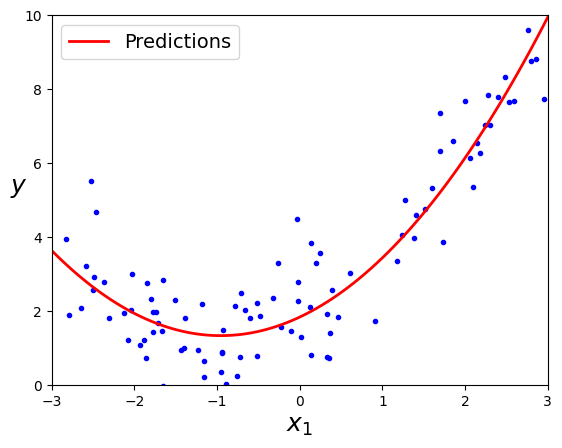

In [5]:
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
#save_fig("quadratic_predictions_plot")
plt.show()

Not bad: the model estimates $y = 0.50x_1^2 + 0.97x_1 + 1.79$   
    when in fact the original
function was $y = 0.5x_1^2 + 1.0x_1 + 2.0 +$ Gaussian noise.

## Key Takeaways

- **Polynomial Regression** is a way to model **nonlinear relationships** using **linear models**.
- It works by adding **powers of the input features** as new features.
- The model remains **linear in the parameters**, so standard linear regression techniques still apply.
- Higher degrees allow more flexibility, but also increase the risk of **overfitting**.


## Polynomial Regression with Multiple Features

Note that when there are **multiple features**, Polynomial Regression is capable of finding **relationships between features** — something a plain Linear Regression model cannot do.

This is made possible because **`PolynomialFeatures`** also adds **all combinations of features** up to the given degree.

For example, if there are two features **a** and **b**, then using:

$$
\text{PolynomialFeatures(degree=3)}
$$

will not only add the individual powers:

$$
a^2, \quad a^3, \quad b^2, \quad b^3
$$

but also the **interaction terms** between features:

$$
ab, \quad a^2b, \quad ab^2
$$

Thus, the model can capture **nonlinear interactions** between features, enabling it to learn much more complex relationships in the data.


## Feature Growth in Polynomial Regression

The transformation performed by **PolynomialFeatures(degree = d)** can greatly increase the number of features.

Specifically, if the original dataset contains **n** features, then after transformation, the new feature matrix will contain:

$$
\frac{(n + d)!}{d! \, n!}
$$

features.

Here, **n!** denotes the factorial of **n**, defined as:

$$
n! = 1 \times 2 \times 3 \times \cdots \times n
$$

⚠️ **Beware of the combinatorial explosion!**

As **n** or **d** increases, the number of resulting features grows **very rapidly**, leading to increased computational cost and a higher risk of **overfitting**.


If you perform high-degree Polynomial Regression, you will likely fit the training  
data much better than with plain Linear Regression. For example, Figure below applies  
a 300-degree polynomial model to the preceding training data, and compares the  
result with a pure linear model and a quadratic model (second-degree polynomial).  
Notice how the 300-degree polynomial model wiggles around to get as close as possi‐
ble to the training instances.

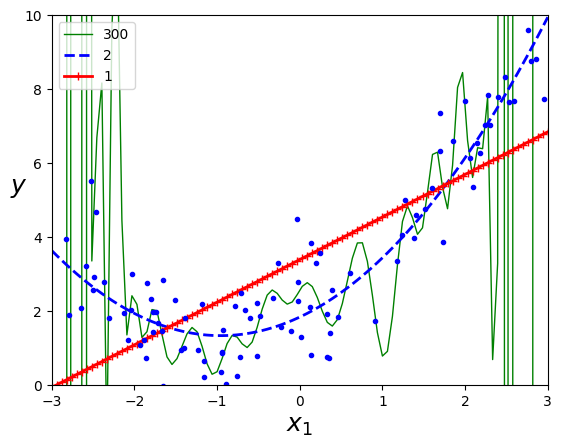

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 1)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
#save_fig("high_degree_polynomials_plot")
plt.show()


 Compared with a linear model and a quadratic (degree 2) model:

- The **300-degree model** wiggles around to get as close as possible to the training instances.  
- This model is **severely overfitting** the training data.  
- The **linear model** is **underfitting**, failing to capture the underlying pattern.  
- The **quadratic model** generalizes best, which aligns with the fact   
that the data was generated using a quadratic function.  

In practice, you usually **don’t know the true underlying function**.    
So how do you decide the **complexity of your model**?  
How can you tell if it is **overfitting** or **underfitting**?

---

## Detecting Overfitting and Underfitting

1. **Cross-validation**:  
   - If a model performs **well on training data** but **poorly on validation data**, it is **overfitting**.  
   - If it performs **poorly on both training and validation sets**, it is **underfitting**.  

2. **Learning Curves**:  
   - A **learning curve** plots the model’s performance on the **training set** and **validation set** as a   
function of the **training set size** (or **training iterations**).  
   - To generate learning curves, train the model multiple times on subsets of the training data  
    and record the performance metrics.

The following code defines a function to **plot learning curves** for a given model and dataset.



## Learning Curves for Linear Regression

Let's visualize the learning curves of a **plain Linear Regression model** (a straight line) on our quadratic data.

We will use the `plot_learning_curves` function to see how the training and validation errors change as we increase the training set size.


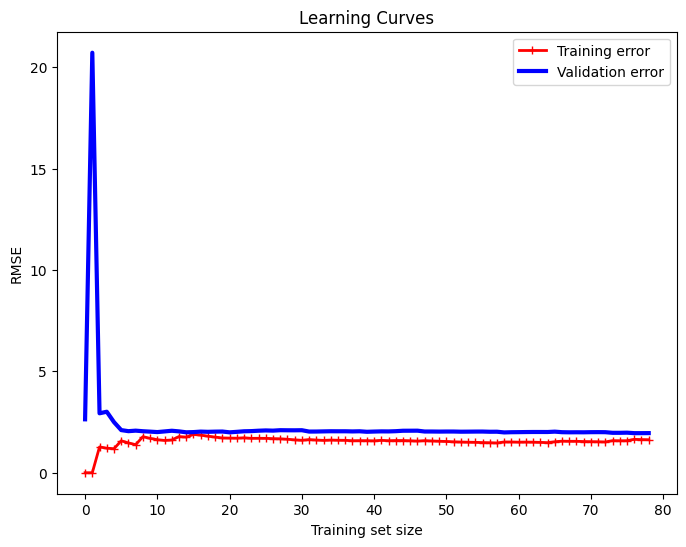

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

def plot_learning_curves(model, X, y):
    # Split data into training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    
    train_errors, val_errors = [], []
    
    for m in range(1, len(X_train)):
        # Train model on subset of training data
        model.fit(X_train[:m], y_train[:m])
        # Predictions
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        # Record RMSE
        train_errors.append(np.sqrt(mean_squared_error(y_train[:m], y_train_predict)))
        val_errors.append(np.sqrt(mean_squared_error(y_val, y_val_predict)))
    
    # Plot learning curves
    plt.figure(figsize=(8,6))
    plt.plot(train_errors, "r-+", linewidth=2, label="Training error")
    plt.plot(val_errors, "b-", linewidth=3, label="Validation error")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.title("Learning Curves")
    plt.legend()
    plt.show()

# Create a plain linear regression model
lin_reg = LinearRegression()

# Plot learning curves
plot_learning_curves(lin_reg, X, y)


## Explaining Underfitting with Learning Curves

The learning curves of a **linear model** on nonlinear data illustrate **underfitting**. Here's why:

1. **Training Error Behavior**  
   - When there are just **one or two instances** in the training set, the model can fit them perfectly, so the training error starts at **zero**.  
   - As more instances are added, the model cannot fit the training data perfectly because:  
     - The data is **noisy**, and  
     - The true relationship is **not linear**.  
   - Consequently, the **training error increases** until it reaches a **plateau**, where adding more training instances doesn't significantly change the average error.

2. **Validation Error Behavior**  
   - When trained on **very few instances**, the model cannot generalize, so the **validation error is initially high**.  
   - As more examples are added, the model gradually learns, and the **validation error decreases slightly**.  
   - However, since a straight line cannot model the data well, the **validation error also plateaus**, ending up close to the training error curve.

3. **Key Takeaways**  
   - Both curves are **high and close to each other**, which is typical of **underfitting**.  
   - In this case, **adding more training data will not help**.  
   - To improve the model, you need:  
     - A **more complex model**, or  
     - **Better feature engineering** to capture the underlying pattern.


NOTE: If your model is underfitting the training data, adding more train‐
ing examples will not help. You need to use a more complex model
or come up with better features.

Now let’s look at the learning curves of a 10th-degree polynomial model on the same



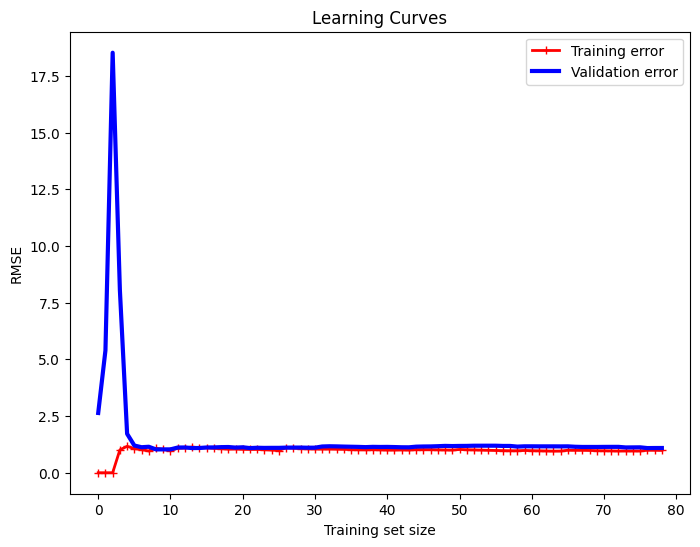

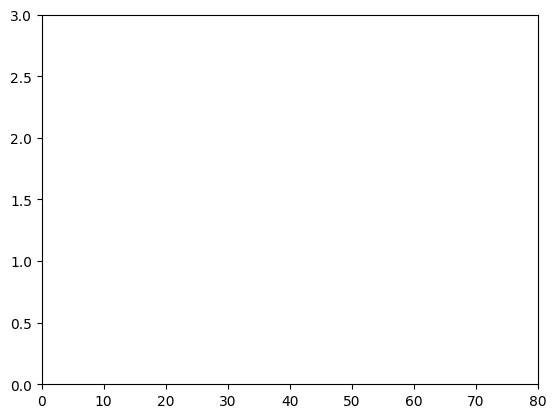

In [9]:
from sklearn.pipeline import Pipeline

polynomial_regression = Pipeline([
        ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
        ("lin_reg", LinearRegression()),
    ])

plot_learning_curves(polynomial_regression, X, y)
plt.axis([0, 80, 0, 3])           # not shown
#save_fig("learning_curves_plot")  # not shown
plt.show() 

These learning curves look a bit like the previous ones, but there are two very impor‐
tant differences:

    • The error on the training data is much lower than with the Linear Regression model.
    • There is a gap between the curves. This means that the model performs significantly  
      better on the training data than on the validation data, which is the hallmark of  
      an overfitting model. If you used a much larger training set, however, the two curves  
      would continue to get closer.

- One way to improve an overfitting model is to feed it more training  
data until the validation error reaches the training error.

## The Bias/Variance Trade-off

An important theoretical concept in **statistics** and **machine learning** is that a model’s **generalization error** can be decomposed into three distinct components:

$$
\text{Generalization Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible Error}
$$

---

### 1. **Bias**

- **Bias** represents the error introduced by making **simplifying assumptions** about the data.  
- For example, assuming the data is **linear** when it is actually **quadratic** introduces high bias.  
- A **high-bias model** tends to **underfit** the training data.

---

### 2. **Variance**

- **Variance** refers to the model’s **sensitivity to small variations** in the training data.  
- Models with many degrees of freedom—such as **high-degree polynomial models**—tend to have **high variance**, meaning they **overfit** the training data.

---

### 3. **Irreducible Error**

- This component arises from the **inherent noise** in the data itself.  
- It cannot be eliminated unless the data quality improves.  
  - For example, by fixing faulty sensors or removing outliers.  

---

### ⚖️ The Trade-off

- **Increasing model complexity** ⟶ decreases **bias** but increases **variance**.  
- **Decreasing model complexity** ⟶ increases **bias** but decreases **variance**.  

This tension between bias and variance is known as the **Bias–Variance Trade-off**.  
Finding the right balance is crucial for achieving **good generalization performance**.


# Regularized Linear Models

As we saw in Chapters 1 and 2, a good way to reduce overfitting is to **regularize the model** (i.e., to constrain it):  
the fewer degrees of freedom it has, the harder it will be for it to overfit the data.  

A simple way to regularize a polynomial model is to reduce the number of polynomial degrees.

For a linear model, regularization is typically achieved by **constraining the weights** of the model.  
We will now look at **Ridge Regression**, **Lasso Regression**, and **Elastic Net**,  
which implement three different ways to constrain the weights.

---

## Ridge Regression

**Ridge Regression** (also called **Tikhonov regularization**) is a regularized version of Linear Regression:  
a regularization term equal to  

$$
\alpha \sum_{i=1}^{n} \theta_i^2
$$  

is added to the cost function.  
This forces the learning algorithm to not only fit the data but also keep the model weights as small as possible.  

Note that the regularization term should only be added to the cost function **during training**.  
Once the model is trained, you want to use the unregularized performance measure to evaluate the model’s performance.

---

> It is quite common for the cost function used during training to be different from the performance measure used for testing.  
> Apart from regularization, another reason they might be different is that a good training cost function should have optimization-friendly derivatives,  
> while the performance measure used for testing should be as close as possible to the final objective.  
> For example, classifiers are often trained using a cost function such as the log loss (discussed later) but evaluated using precision/recall.

---

The hyperparameter **α** controls how much you want to regularize the model.

- If **α = 0**, then Ridge Regression is just Linear Regression.  
- If **α** is very large, then all weights end up very close to zero and the result is a flat line going through the data’s mean.  

Equation 4-8 presents the Ridge Regression cost function:

$$
J(\theta) = \text{MSE}(\theta) + \frac{\alpha}{2} \sum_{i=1}^{n} \theta_i^2
$$

---

Note that the **bias term** $ \theta_0 $ is **not regularized** (the sum starts at *i = 1*, not *0*).  

If we define **w** as the vector of feature weights ($\theta_1$ to $\theta_n$),  
then the regularization term is equal to  

$$
\frac{1}{2} \| w \|_2^2
$$  

where $ \| w \|_2 $ represents the $\mathcal{l}_2$ norm of the weight vector.  

For **Gradient Descent**, just add **αw** to the MSE gradient vector 

---

> It is important to scale the data (e.g., using a `StandardScaler`) before performing Ridge Regression,  
> as it is sensitive to the scale of the input features.  
> This is true of most regularized models.

---

Figure below shows several Ridge models trained on some linear data using different α values.  
On the left, plain Ridge models are used, leading to linear predictions.  
On the right, the data is first expanded using:
```python
PolynomialFeatures(degree=10)

then it is scaled using a StandardScaler, and finally the Ridge models are applied to the result‐
ing features: this is Polynomial Regression with Ridge regularization. Note how
increasing α leads to flatter (i.e., less extreme, more reasonable) predictions, thus
reducing the model’s variance but increasing its bias.



In [12]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

In [13]:
from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55071465]])

In [44]:
ridge_reg = Ridge(alpha=1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55072189]])

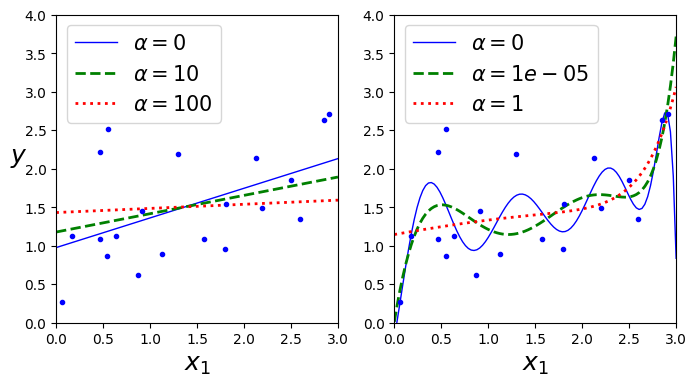

In [14]:
from sklearn.linear_model import Ridge

def plot_model(model_class, polynomial, alphas, **model_kargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                    ("std_scaler", StandardScaler()),
                    ("regul_reg", model),
                ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)

#save_fig("ridge_regression_plot")
plt.show()

A linear model (left) and a polynomial model (right), both with various lev‐
els of Ridge regularization

# Ridge Regression: Closed-Form vs Gradient Descent

As with Linear Regression, Ridge Regression can be performed either by:

1. **Closed-form solution**  
2. **Gradient Descent (or Stochastic Gradient Descent)**  

The pros and cons are the same as for Linear Regression.

---

## Closed-Form Solution

Equation below shows the closed-form solution, where **A** is the $$(n + 1) \times (n + 1)$$ identity matrix,  
except with a **0** in the top-left cell corresponding to the bias term.

$$
\theta = \left( X^\top X + \alpha A \right)^{-1} X^\top y
$$

This can be implemented in Scikit-Learn using the `cholesky` solver.

---



In [47]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)


from sklearn.linear_model import Ridge
ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55071465]])

In [48]:
ridge_reg = Ridge(alpha=1, solver="sag", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55072189]])

## Gradient Descent (Stochastic)

You can also perform Ridge Regression using **Stochastic Gradient Descent (SGD)**.  

The `penalty` hyperparameter specifies the type of regularization:

- `"l2"` indicates Ridge Regression (ℓ2 norm penalty):

$$
\frac{1}{2} \| w \|_2^2
$$


In [1]:
from sklearn.linear_model import SGDRegressor
>>> sgd_reg = SGDRegressor(penalty="l2")
>>> sgd_reg.fit(X, y.ravel())
>>> sgd_reg.predict([[1.5]])


NameError: name 'X' is not defined

The penalty hyperparameter sets the type of regularization term to use. Specifying
"l2" indicates that you want SGD to add a regularization term to the cost function
equal to half the square of the ℓ2 norm of the weight vector: this is simply Ridge
Regression.

# 🧮 Lasso Regression

**Least Absolute Shrinkage and Selection Operator Regression (Lasso Regression)**  
is another **regularized** version of Linear Regression. Just like Ridge Regression, it  
adds a **regularization term** to the cost function — but instead of using the squared  
$\ell_2$ norm, it uses the $\ell_1$ norm of the weight vector.

---

## 📘 Equation 4-10: Lasso Regression Cost Function

$$
J(\theta) = \text{MSE}(\theta) + \alpha \sum_{i=1}^{n} |\theta_i|
$$

---

### ⚙️ Key Idea

A remarkable property of Lasso Regression is that it **tends to eliminate the weights**  
of less important features — in other words, it can automatically perform **feature selection**  
by setting some coefficients exactly to zero.  

This results in a **sparse model**, where only a subset of the features contribute to predictions.

For instance, with a high-degree polynomial model and a small value of $\alpha$ (e.g. $\alpha = 10^{-7}$),  
the Lasso Regression curve may appear almost quadratic or even linear — because all higher-degree  
feature weights are driven to zero.

---

### 🧭 Geometric Intuition

To understand *why* this happens, consider the following:

- The **axes** represent two model parameters, $\theta_1$ and $\theta_2$.
- The **background contours** represent different loss functions.

#### 🔹 ℓ₁ Loss Landscape

For the $\ell_1$ loss ($|\theta_1| + |\theta_2|$), the contours form **diamond-shaped** levels.  
When running Gradient Descent, both parameters decrease equally along the gradient path.  
However, since $\theta_2$ may start closer to zero, it will reach zero first — effectively **shrinking** to zero and staying there.  
After that, the optimization “slides along the gutter” (the axis) until convergence.

---

#### 🔹 Lasso Cost Function (MSE + ℓ₁ Penalty)

When combining the **MSE** term and the **ℓ₁** penalty:

- The optimization path first drives smaller parameters to zero.
- Then it proceeds along one axis to reach the global minimum (red square).
- Increasing $\alpha$ moves the optimal point **toward the origin**, increasing regularization.
- Decreasing $\alpha$ moves it **away from the origin**, reducing regularization.

---

### 🆚 Comparison with Ridge Regression

| Aspect | Lasso Regression | Ridge Regression |
|--------|------------------|------------------|
| Regularization Type | $\ell_1$ norm | $\ell_2$ norm |
| Effect on Coefficients | Some become exactly zero (feature selection) | All shrink but remain nonzero |
| Model Sparsity | Produces sparse models | Produces dense models |
| Optimization Shape | Diamond-like (sharp corners) | Circular (smooth) |

---

### 💡 Summary

- Lasso = $\ell_1$ regularization → **Feature Selection + Sparsity**
- Ridge = $\ell_2$ regularization → **Shrinkage without elimination**


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.803e+00, tolerance: 9.295e-04
  model = cd_fast.enet_coordinate_descent(


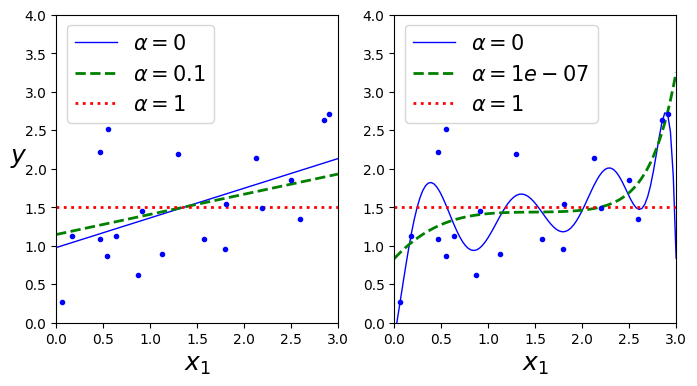

In [54]:
from sklearn.linear_model import Lasso

plt.figure(figsize=(8,4))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 10**-7, 1), random_state=42)

#save_fig("lasso_regression_plot")
plt.show()

In [55]:
from sklearn.linear_model import Lasso

# Create and fit a Lasso Regression model
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)

# Predict new data point
lasso_reg.predict([[1.5]])


array([1.53788174])

An important characteristic of Lasso Regression is that it tends to eliminate the
weights of the least important features (i.e., set them to zero). For example, the
dashed line in the righthand plot in Figure below (with α = 10-7) looks quadratic,
almost linear: all the weights for the high-degree polynomial features are equal to
zero. In other words, Lasso Regression automatically performs feature selection and
outputs a sparse model (i.e., with few nonzero feature weights).

# Lasso Regression

The Lasso cost function is **not differentiable** at \( \theta_i = 0 \) (for \( i = 1, 2, \ldots, n \)),  
but **Gradient Descent** still works fine if you use a **subgradient vector** \( g \) instead when any \( \theta_i = 0 \).

Equation 4-11 shows a subgradient vector equation you can use for Gradient Descent with the **Lasso cost function**.

---

### Equation 4-11. Lasso Regression Subgradient Vector

$$
g(\theta, J) = \nabla_\theta \text{MSE}(\theta) + \alpha 
\begin{bmatrix}
\text{sign}(\theta_1) \\
\text{sign}(\theta_2) \\
\vdots \\
\text{sign}(\theta_n)
\end{bmatrix}
$$

where

$$
\text{sign}(\theta_i) =
\begin{cases}
-1, & \text{if } \theta_i < 0 \\
0,  & \text{if } \theta_i = 0 \\
+1, & \text{if } \theta_i > 0
\end{cases}
$$

---

### Scikit-Learn Implementation
Here is a small **Scikit-Learn** example using the `Lasso` class:


In [56]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])


array([1.53788174])

# Elastic Net Regression

**Elastic Net Regression** is a regularized regression method that combines both **Ridge** and **Lasso** penalties.  
It aims to balance between the \( \ell_1 \) norm (which promotes sparsity) and the \( \ell_2 \) norm (which stabilizes the solution).

The **Elastic Net cost function** is given by:

---

### Equation 4-12. Elastic Net Cost Function

$$
J(\theta) = \text{MSE}(\theta) + r \, \alpha \sum_{i=1}^{n} |\theta_i| + \frac{1 - r}{2} \, \alpha \sum_{i=1}^{n} \theta_i^2
$$

where:

- $ \alpha $ controls the **overall regularization strength**,  
- $ r $ (called `l1_ratio` in Scikit-Learn) controls the **mix ratio** between Lasso ($ \ell_1 $) and Ridge ($ \ell_2 $) penalties:
  - $ r = 0 $: equivalent to **Ridge Regression**
  - $ r = 1 $: equivalent to **Lasso Regression**
  - $ 0 < r < 1 $: **Elastic Net**

---

### Scikit-Learn Implementation


So when should you use plain Linear Regression (i.e., without any regularization),  
Ridge, Lasso, or Elastic Net? It is almost always preferable to have at least a   
little bit of
regularization, so generally you should avoid plain Linear Regression. Ridge is a good  
default, but if you suspect that only a few features are useful, you should prefer Lasso  
or Elastic Net because they tend to reduce the useless features’ weights down to zero,  
as we have discussed. In general, Elastic Net is preferred over Lasso because Lasso   
may behave erratically when the number of features is greater than the number of  
training instances or when several features are strongly correlated.  
Here is a short example that uses Scikit-Learn’s ElasticNet (l1_ratio corresponds to  
the mix ratio r):

In [57]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])


array([1.54333232])

# Early Stopping

**Early Stopping** is a simple yet powerful **regularization technique** for iterative optimization algorithms like **Gradient Descent**.

Instead of letting the model train until full convergence, we **monitor the validation error** and **stop training** once this error stops decreasing.

This prevents the model from **overfitting** the training data.

---

### Concept

During training:

- The **training error** (e.g., RMSE on the training set) continues to decrease.
- The **validation error** initially decreases but then starts increasing once the model begins to overfit.

At that turning point, **training should be stopped** — this is the essence of early stopping.

---

### Mathematical Idea

Let  $J_{\text{train}}(\theta) $ and $ J_{\text{val}}(\theta) $ denote the training and validation errors respectively.

Training is stopped at epoch $ t^* $such that:

$$
t^* = \arg \min_t J_{\text{val}}(\theta_t)
$$

After this point, additional training will reduce $ J_{\text{train}} $ but increase $ J_{\text{val}} $, signaling **overfitting**.

---

### Example: Early Stopping with Scikit-Learn


In [65]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

# Generate synthetic data
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 2 + X**2 + X + np.random.randn(m, 1)

# Split into train/validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Polynomial features and scaling
poly_scaler = Pipeline([
    ("poly", PolynomialFeatures(degree=10, include_bias=False)),
    ("scaler", StandardScaler())
])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

# Model setup
sgd_reg = SGDRegressor(max_iter=1, tol=10^6, penalty=None, eta0=0.0005, warm_start=True, random_state=42)

min_val_error = float("inf")
best_epoch = None
best_model = None

for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train.ravel())
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < min_val_error:
        min_val_error = val_error
        best_epoch = epoch
        best_model = sgd_reg
    else:
        # Stop if validation error increases
        break

best_epoch, min_val_error


/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

(606, 0.5957241503653778)

---

### Discussion

- The **best epoch** corresponds to the lowest validation error.
- Training beyond this point would cause **overfitting**.
- Early stopping thus **acts as implicit regularization** by limiting the model's effective capacity.

---

### Visualization (optional)

You can plot the training and validation RMSE versus epochs to **visualize** when overfitting starts:



In [58]:
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 2 + X + 0.5 * X**2 + np.random.randn(m, 1)

X_train, X_val, y_train, y_val = train_test_split(X[:50], y[:50].ravel(), test_size=0.5, random_state=10)

In [60]:
from copy import deepcopy

poly_scaler = Pipeline([
        ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
        ("std_scaler", StandardScaler())
    ])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_reg = SGDRegressor(max_iter=1, tol=10^4, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train)  # continues where it left off
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = deepcopy(sgd_reg)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:1548: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

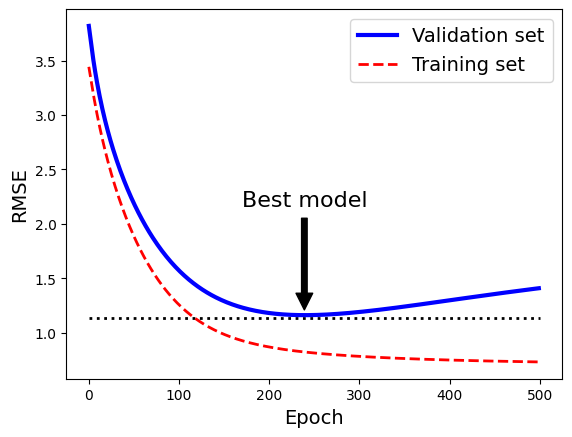

In [62]:
sgd_reg = SGDRegressor(max_iter=1, tol=10^4, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

n_epochs = 500
train_errors, val_errors = [], []
for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_train_predict = sgd_reg.predict(X_train_poly_scaled)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    train_errors.append(mean_squared_error(y_train, y_train_predict))
    val_errors.append(mean_squared_error(y_val, y_val_predict))

best_epoch = np.argmin(val_errors)
best_val_rmse = np.sqrt(val_errors[best_epoch])

plt.annotate('Best model',
             xy=(best_epoch, best_val_rmse),
             xytext=(best_epoch, best_val_rmse + 1),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=16,
            )

best_val_rmse -= 0.03  # just to make the graph look better
plt.plot([0, n_epochs], [best_val_rmse, best_val_rmse], "k:", linewidth=2)
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation set")
plt.plot(np.sqrt(train_errors), "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
#save_fig("early_stopping_plot")
plt.show()

The plot typically shows:

- **Training RMSE** decreasing steadily.
- **Validation RMSE** decreasing first, then increasing after a point.

That inflection point indicates where to stop training — the **optimal epoch**.

---

**Geoffrey Hinton** famously called Early Stopping a:

> “Beautiful free lunch” —  
> because it gives you regularization *for free* without modifying the model or cost function.
